# Python EDA

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
import plotly.express as px

In [52]:
d1 = pd.read_csv(r"C:\Users\KIIT\OneDrive\Desktop\data analytics 3.0\student-mat.csv", sep=";")
d2 = pd.read_csv(r"C:\Users\KIIT\OneDrive\Desktop\data analytics 3.0\student-por.csv", sep=";")

d3 = pd.merge(d1, d2, 
              on=["school","sex","age","address","famsize","Pstatus",
                  "Medu","Fedu","Mjob","Fjob","reason","nursery","internet"])

print(len(d3))
d3 = d3.reset_index(drop=True)
d3.index = d3.index + 1

382


## Data Pre-Processing

In [53]:
#Displays the first 10 rows of the merged dataset
d3.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_y,freetime_y,goout_y,Dalc_y,Walc_y,health_y,absences_y,G1_y,G2_y,G3_y
1,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
2,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
3,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
4,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
5,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
6,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
7,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,13,12,13
8,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
9,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,15,16,17
10,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13


In [54]:
#Displays the first 10 rows of the merged dataset
d3.tail(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_y,freetime_y,goout_y,Dalc_y,Walc_y,health_y,absences_y,G1_y,G2_y,G3_y
373,MS,M,19,R,GT3,T,1,1,other,services,...,4,3,2,1,3,5,0,5,8,0
374,MS,M,18,R,GT3,T,4,2,other,other,...,5,4,3,4,3,3,0,7,7,0
375,MS,F,18,R,GT3,T,2,2,at_home,other,...,5,3,3,1,3,4,0,14,17,15
376,MS,F,18,R,GT3,T,4,4,teacher,at_home,...,4,4,3,2,2,5,4,7,9,10
377,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
378,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
379,MS,F,18,U,GT3,T,1,1,other,other,...,3,4,4,2,2,5,3,7,8,7
380,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
381,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10
382,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,4,10,11,11


In [55]:
#Gives the summary of the merged dataset
d3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 1 to 382
Data columns (total 53 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   school        382 non-null    object
 1   sex           382 non-null    object
 2   age           382 non-null    int64 
 3   address       382 non-null    object
 4   famsize       382 non-null    object
 5   Pstatus       382 non-null    object
 6   Medu          382 non-null    int64 
 7   Fedu          382 non-null    int64 
 8   Mjob          382 non-null    object
 9   Fjob          382 non-null    object
 10  reason        382 non-null    object
 11  guardian_x    382 non-null    object
 12  traveltime_x  382 non-null    int64 
 13  studytime_x   382 non-null    int64 
 14  failures_x    382 non-null    int64 
 15  schoolsup_x   382 non-null    object
 16  famsup_x      382 non-null    object
 17  paid_x        382 non-null    object
 18  activities_x  382 non-null    object
 19  nursery 

In [56]:
#Gives the statistical summary of the numerical columns
d3.describe()

,age,Medu,Fedu,traveltime_x,studytime_x,failures_x,famrel_x,freetime_x,goout_x,Dalc_x,...,famrel_y,freetime_y,goout_y,Dalc_y,Walc_y,health_y,absences_y,G1_y,G2_y,G3_y
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,...,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,16.586387,2.806283,2.565445,1.442408,2.034031,0.290576,3.939791,3.222513,3.112565,1.473822,...,3.942408,3.230366,3.117801,1.476440,2.290576,3.575916,3.672775,12.112565,12.238220,12.515707
std,1.173470,1.086381,1.096240,0.695378,0.845798,0.729481,0.921620,0.988233,1.131927,0.886229,...,0.908884,0.985096,1.133710,0.886303,1.282577,1.404248,4.905965,2.556531,2.468341,2.945438
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,5.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,...,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,10.000000,11.000000,11.000000
50%,17.000000,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,...,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,12.000000,12.000000,13.000000
75%,17.000000,4.000000,4.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,...,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,14.000000,14.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [57]:
#Total number of rows and columns in the merged dataset
d3.shape

(382, 53)

## Data Processing

In [58]:
#Sorts the mother's education level as experience
d3.sort_values(by="Medu")


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_y,freetime_y,goout_y,Dalc_y,Walc_y,health_y,absences_y,G1_y,G2_y,G3_y
318,GP,F,17,U,LE3,T,0,2,at_home,at_home,...,3,3,3,2,3,2,0,14,14,15
131,GP,F,19,U,GT3,T,0,1,at_home,other,...,3,4,2,1,1,5,0,9,10,11
252,GP,M,16,U,GT3,T,0,2,other,other,...,4,3,2,2,4,5,0,11,12,11
379,MS,F,18,U,GT3,T,1,1,other,other,...,3,4,4,2,2,5,3,7,8,7
373,MS,M,19,R,GT3,T,1,1,other,services,...,4,3,2,1,3,5,0,5,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,GP,F,15,U,GT3,T,4,4,teacher,health,...,3,3,3,1,2,2,2,14,14,14
8,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13
6,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,6,12,12,13
4,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14


In [59]:
# Count number of males and females
d3['sex'].value_counts()

sex
F    198
M    184
Name: count, dtype: int64

In [60]:
d3.groupby('sex')['G3_math'].mean()

KeyError: 'Column not found: G3_math'

In [ ]:
d3.groupby('sex')['G3_por'].mean()

sex
Female    11.902174
Male      13.085859
Name: G3_por, dtype: float64

In [ ]:
#Sorts the father's education level as experience
d3.sort_values(by="Fedu")

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_y,freetime_y,goout_y,Dalc_y,Walc_y,health_y,absences_y,G1_y,G2_y,G3_y
77,GP,M,15,U,GT3,T,4,0,teacher,other,...,3,4,3,1,1,1,0,12,11,11
172,GP,M,16,U,GT3,T,1,0,other,other,...,4,3,2,1,1,3,0,16,17,18
380,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
2,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
379,MS,F,18,U,GT3,T,1,1,other,other,...,3,4,4,2,2,5,3,7,8,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13,GP,M,15,U,LE3,T,4,4,health,services,...,4,3,3,1,3,5,0,12,13,12
10,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,12,12,13
11,GP,F,15,U,GT3,T,4,4,teacher,health,...,3,3,3,1,2,2,2,14,14,14
8,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,2,10,13,13


In [ ]:
#Sorts the age group of candidates in ascending order from 15-22
d3.sort_values(by="age")

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel_y,freetime_y,goout_y,Dalc_y,Walc_y,health_y,absences_y,G1_y,G2_y,G3_y
33,GP,M,15,R,GT3,T,4,3,teacher,at_home,...,4,5,2,1,1,5,0,13,14,15
34,GP,M,15,U,LE3,T,3,3,other,other,...,5,3,2,1,1,2,0,13,12,12
36,GP,F,15,U,GT3,T,2,3,other,other,...,3,5,1,1,1,5,4,11,11,11
37,GP,M,15,U,LE3,T,4,3,teacher,services,...,5,4,3,1,1,4,0,14,14,14
39,GP,F,15,R,GT3,T,3,4,services,health,...,4,3,2,1,1,5,2,11,12,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
309,GP,M,19,R,GT3,T,3,3,other,services,...,4,5,3,1,2,5,0,10,10,11
300,GP,F,19,U,GT3,T,4,4,health,other,...,2,3,4,2,3,2,2,14,13,13
273,GP,F,19,U,GT3,T,3,3,other,services,...,4,3,5,3,3,5,16,11,12,12
308,GP,M,20,U,GT3,A,3,2,services,other,...,5,5,3,1,1,5,0,14,15,15


## Data Cleaning

In [ ]:
#Check for missing values
print("\nMissing values:")
print(d3.isnull().sum())


Missing values:
school          0
sex             0
age             0
address         0
famsize         0
Pstatus         0
Medu            0
Fedu            0
Mjob            0
Fjob            0
reason          0
guardian_x      0
traveltime_x    0
studytime_x     0
failures_x      0
schoolsup_x     0
famsup_x        0
paid_x          0
activities_x    0
nursery         0
higher_x        0
internet        0
romantic_x      0
famrel_x        0
freetime_x      0
goout_x         0
Dalc_x          0
Walc_x          0
health_x        0
absences_x      0
G1_x            0
G2_x            0
G3_x            0
guardian_y      0
traveltime_y    0
studytime_y     0
failures_y      0
schoolsup_y     0
famsup_y        0
paid_y          0
activities_y    0
higher_y        0
romantic_y      0
famrel_y        0
freetime_y      0
goout_y         0
Dalc_y          0
Walc_y          0
health_y        0
absences_y      0
G1_y            0
G2_y            0
G3_y            0
dtype: int64


In [ ]:
#Check for duplicate rows
print("\nDuplicate rows:")
print(d3.duplicated().sum())



Duplicate rows:
0


In [ ]:
d3.rename(columns={
    'G1_x': 'G1_math',
    'G1_y': 'G1_por',
    'G2_x': 'G2_math',
    'G2_y': 'G2_por',
    'G3_x': 'G3_math',
    'G3_y': 'G3_por'
}, inplace=True)
print("\nColumns after renaming:")
print(d3.columns)


Columns after renaming:
Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian_x', 'traveltime_x', 'studytime_x',
       'failures_x', 'schoolsup_x', 'famsup_x', 'paid_x', 'activities_x',
       'nursery', 'higher_x', 'internet', 'romantic_x', 'famrel_x',
       'freetime_x', 'goout_x', 'Dalc_x', 'Walc_x', 'health_x', 'absences_x',
       'G1_math', 'G2_math', 'G3_math', 'guardian_y', 'traveltime_y',
       'studytime_y', 'failures_y', 'schoolsup_y', 'famsup_y', 'paid_y',
       'activities_y', 'higher_y', 'romantic_y', 'famrel_y', 'freetime_y',
       'goout_y', 'Dalc_y', 'Walc_y', 'health_y', 'absences_y', 'G1_por',
       'G2_por', 'G3_por'],
      dtype='object')


In [ ]:
# Convert gender column
d3['sex'] = d3['sex'].map({'M': 0, 'F': 1})
print("\nAfter encoding 'sex':")
print(d3[['sex']].head(10))




After encoding 'sex':
    sex
1     1
2     1
3     1
4     1
5     1
6     0
7     0
8     1
9     0
10    0


## Data Visualisation

### 1.Distribution of all features


<Figure size 1400x1000 with 0 Axes>

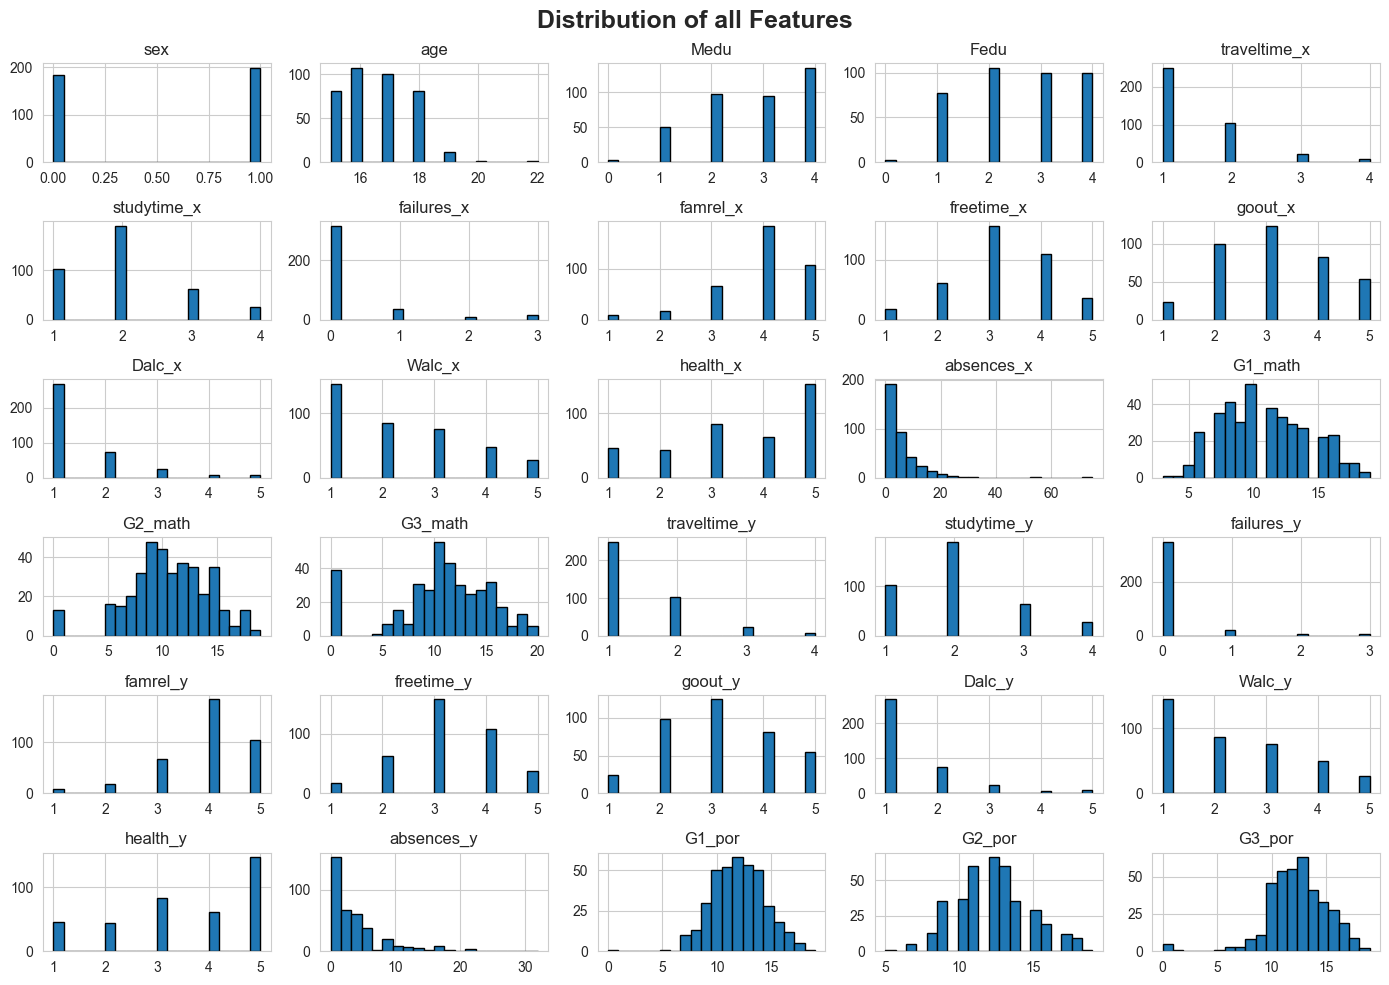

In [ ]:
sb.set_style("whitegrid")
plt.figure(figsize=(14,10))
d3.hist(bins=20, figsize=(14,10), edgecolor='black')
plt.suptitle("Distribution of all Features", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.Gender distribution

C:\Users\KIIT\AppData\Local\Temp\ipykernel_35412\3031144996.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




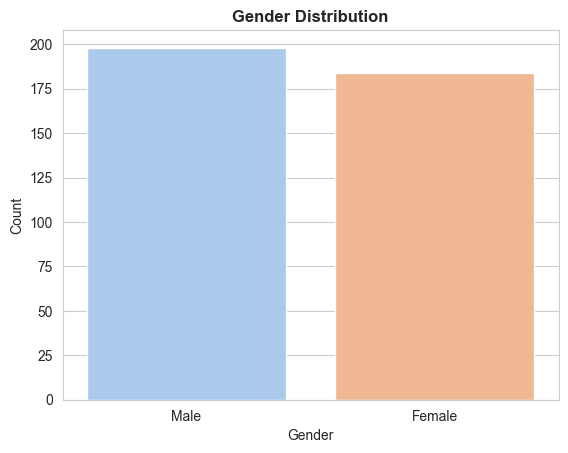

In [ ]:
d3['sex'] = d3['sex'].replace({0: 'Female', 1: 'Male'})
sb.countplot(x='sex', data=d3, palette='pastel')
plt.title("Gender Distribution", fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


### 3.Final Math Grade vs Study Time

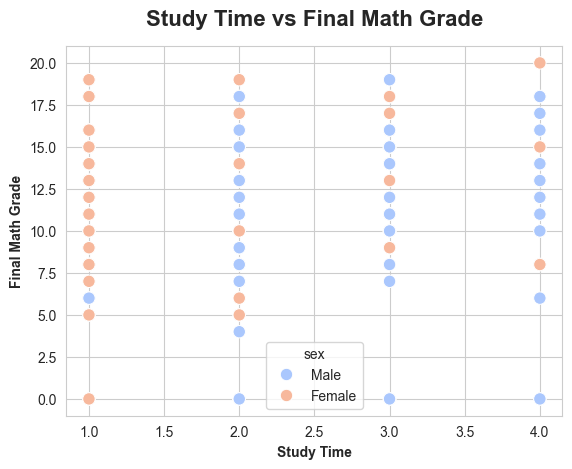

In [ ]:
d3.rename(columns={
    'studytime_x': 'studytime_math',
    'studytime_y': 'studytime_por'
}, inplace=True)
sb.scatterplot(x='studytime_math', y='G3_math', data=d3, 
               hue='sex', palette='coolwarm', s=80)
plt.title("Final Math vs Study Time ", fontsize=16, fontweight='bold')
plt.xlabel("Study Time" , fontweight='bold')
plt.ylabel("Final Math Grade" , fontweight='bold')
plt.title("Study Time vs Final Math Grade", fontsize=16, fontweight='bold', pad=15)
plt.show()

### 4.Correlation Heatmap

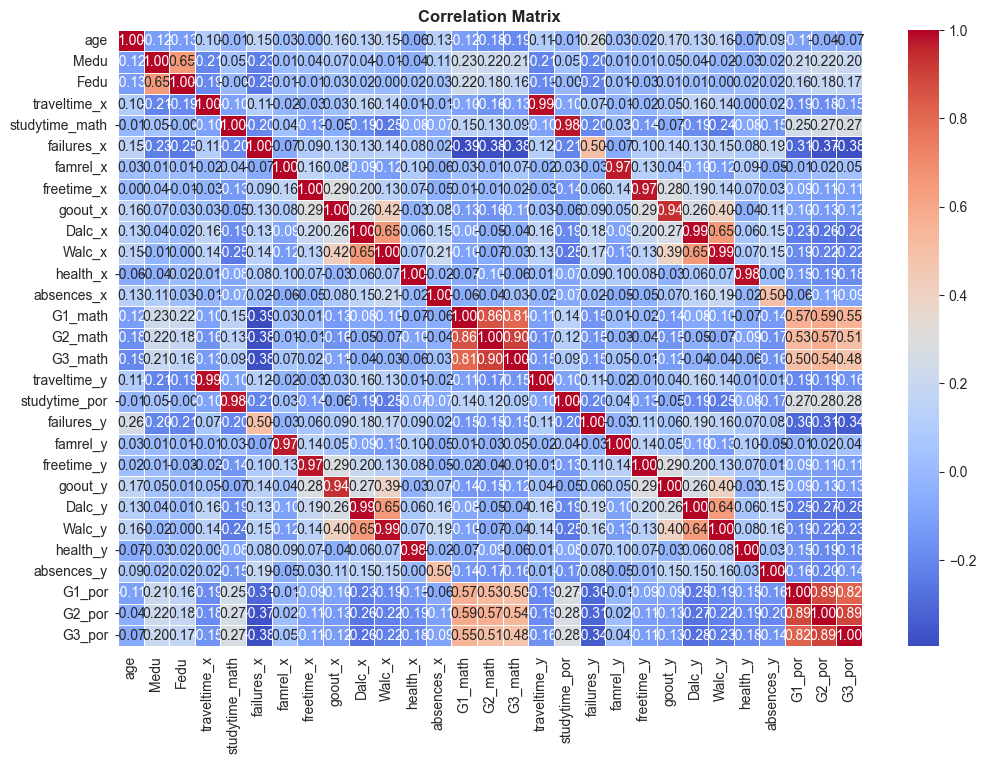

In [ ]:
numeric_data = d3.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,8))
sb.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontweight='bold')
plt.show()

### 5.Average final math grade by gender

C:\Users\KIIT\AppData\Local\Temp\ipykernel_35412\3924142640.py:3: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




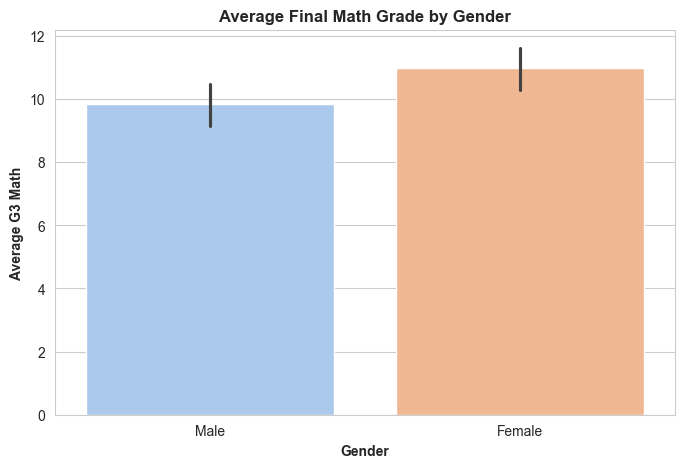

In [ ]:
sb.set_style("whitegrid")
plt.figure(figsize=(8,5))
sb.barplot(x='sex', y='G3_math', data=d3, palette='pastel')
plt.title("Average Final Math Grade by Gender", fontweight='bold')
plt.xlabel("Gender", fontweight='bold')
plt.ylabel("Average G3 Math", fontweight='bold')
plt.show()

### 6.Grade Progression Trend

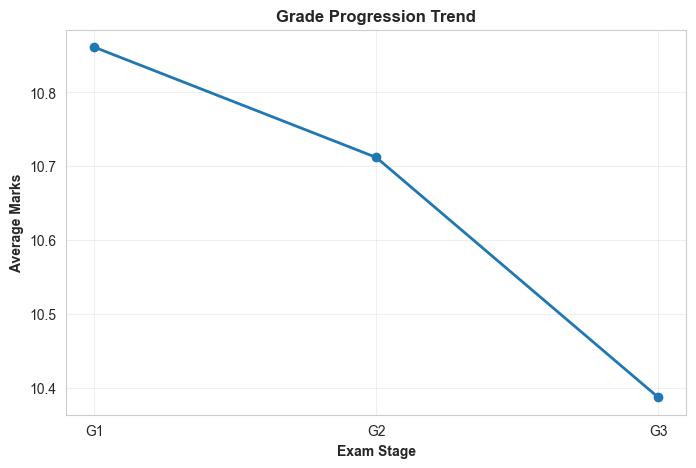

In [ ]:
sb.set_style("whitegrid")
avg_scores = d3[['G1_math','G2_math','G3_math']].mean()
plt.figure(figsize=(8,5))
plt.plot(avg_scores, marker='o', linewidth=2, linestyle='-')
plt.title("Grade Progression Trend", fontweight='bold')
plt.xlabel("Exam Stage", fontweight='bold')
plt.ylabel("Average Marks", fontweight='bold')
plt.xticks([0,1,2], ['G1', 'G2', 'G3'])
plt.grid(alpha=0.3)
plt.show()

### 7.Final Portuguese Grade vs Study Time

In [ ]:
fig = px.scatter(
    d3, 
    x='studytime_por', 
    y='G3_por', 
    color='sex',
    title="Study Time vs Final Portuguese Grade",
    template='plotly_white',
    width=1000,
    height=500    
)
fig.update_layout(
    title_font=dict(
        size=18,
        family="Arial Black"
    ),
    xaxis_title="Study Time",
    yaxis_title="Final Grade (Portuguese)",
    font=dict(
        family="Arial Black",
        size=12
    )
)
fig.show()

## Inisights :

#### 1. Numerical Features Distribution :  Most numerical features (like grades, absences, study time) show non-uniform distributions. Some features are normally distributed, while others are skewed.

#### 2. Gender distribution : The dataset contains both male and female students. The distribution is fairly balanced constituting a total of 192 females students and 184 males students.

#### 3. Final Math Grade vs Study Time : Weak to Moderate Positive Relationship . Students who study more tend to score slightly higher in math. However, the relationship is not very strong.

#### 4. Correlation Heatmap : The correlation heatmap reveals that previous academic performance (G1 and G2) has the strongest influence on final grades. Other factors such as study time, failures, and lifestyle habits show weaker correlations, indicating that student performance is influenced by multiple factors rather than a single variable.

#### 5. Average Math Final Grade by Gender : Usually the difference between male and female students is very negligible . The average ratio of female students is 10.978 and for male students is 9.838.

#### 6. Grade Progression Trend : Final grade depends heavily on previous exams .

#### 7. Final Portuguese Grade vs Study Time : Weak to Moderate Positive Relationship . Students who study more tend to score slightly higher in math. However, the relationship is not very strong.